In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re # For regular expressions

# For NLTK text processing later
import nltk
# nltk.download('stopwords') # Run once if you haven't
# nltk.download('punkt')    # Run once if you haven't
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print("Libraries imported.")

Libraries imported.


In [ ]:
# Load the dataset
file_path = 'raw_analyst_ratings.csv'
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded {file_path}")
except FileNotFoundError:
    print(f"ERROR: File not found at {file_path}. Please ensure it's uploaded to Colab.")
    # You would stop here if the file isn't found. For now, I'll add a placeholder.
    # In a real scenario, you must have the file.
    df = pd.DataFrame() # Create an empty DataFrame to prevent subsequent cells from erroring immediately

if not df.empty:
    print("\nFirst 5 rows of the DataFrame:")
    print(df.head())

    print("\nDataFrame Info:")
    df.info()

    print("\nShape of the DataFrame (rows, columns):")
    print(df.shape)

    print("\nChecking for missing values in each column:")
    print(df.isnull().sum())

    print("\nBasic descriptive statistics for all columns (if applicable):")
    # For large datasets, describe() can be slow on all columns.
    # Let's look at object columns and a sample of numeric if needed.
    print(df.describe(include=['object', 'bool'])) # Stats for non-numeric
    # If you have many numeric columns, you might do df.describe() separately
else:
    print("DataFrame is empty. Cannot proceed with analysis.")

Successfully loaded raw_analyst_ratings.csv

First 5 rows of the DataFrame:
   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:0

In [ ]:
# Assuming df is loaded and not empty from Cell 2
if not df.empty:
    actual_date_column_name = 'date' # You confirmed this is 'date'

    if actual_date_column_name not in df.columns:
        print(f"ERROR: The specified date column '{actual_date_column_name}' does not exist in the DataFrame.")
        print(f"Available columns are: {df.columns.tolist()}")
    else:
        print(f"Processing date column: '{actual_date_column_name}'")

        # Step 1: Attempt to parse all dates.
        # errors='coerce' will turn unparseable dates into NaT (Not a Time).
        # No need for infer_datetime_format anymore in modern pandas
        parsed_dates = pd.to_datetime(df[actual_date_column_name], errors='coerce', utc=False)
        # Using utc=False ensures that if timezone info is present, it's used to make aware datetimes,
        # and if not, it creates naive datetimes.

        # Step 2: Create a new column for our standardized UTC-4 datetimes
        df['datetime_utc4'] = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns, Etc/GMT+4]")

        # Check if any dates were unparseable (NaT)
        initial_nat_mask = parsed_dates.isnull()
        if initial_nat_mask.any():
            print(f"Found {initial_nat_mask.sum()} entries that could not be parsed into dates initially and are NaT.")
            # Copy NaT values to the target column so we don't try to process them further
            df.loc[initial_nat_mask, 'datetime_utc4'] = pd.NaT


        # Step 3: Determine if the parsed_dates Series is naive or aware overall.
        # We'll iterate through non-NaT parsed dates to apply logic.
        # Pandas Series.dt.tz will be None if all datetimes are naive,
        # or a timezone object if all are aware and have the same timezone,
        # or a Series of tzinfo objects if they are mixed (or some are naive, some aware).

        for idx, dt_val in parsed_dates[~initial_nat_mask].items(): # Process only non-NaT values
            if dt_val.tzinfo is None:
                # It's a naive datetime, localize to Etc/GMT+4
                try:
                    df.loc[idx, 'datetime_utc4'] = pd.Timestamp(dt_val).tz_localize('Etc/GMT+4', ambiguous='NaT', nonexistent='NaT')
                except Exception as e:
                    print(f"Warning: Could not localize naive datetime at index {idx}: {dt_val}. Error: {e}")
                    df.loc[idx, 'datetime_utc4'] = pd.NaT # Mark as NaT if localization fails
            else:
                # It's an aware datetime, convert to Etc/GMT+4
                try:
                    df.loc[idx, 'datetime_utc4'] = pd.Timestamp(dt_val).tz_convert('Etc/GMT+4')
                except Exception as e:
                    print(f"Warning: Could not convert aware datetime at index {idx}: {dt_val}. Error: {e}")
                    df.loc[idx, 'datetime_utc4'] = pd.NaT # Mark as NaT if conversion fails

        num_successfully_processed = df['datetime_utc4'].notnull().sum()
        print(f"Successfully processed {num_successfully_processed} dates into 'datetime_utc4'.")

        print("\nFirst 5 entries of the new 'datetime_utc4' column and their types:")
        print(df[['datetime_utc4', actual_date_column_name]].head())
        print("\nInfo for 'datetime_utc4' column:")
        print(df['datetime_utc4'].dtype)

        # Count NaTs that might have resulted from parsing errors or localization/conversion issues
        nat_count_in_datetime_utc4 = df['datetime_utc4'].isnull().sum()
        original_valid_dates_count = df[actual_date_column_name].dropna().shape[0] # Count non-NaN original date strings

        problematic_conversions = nat_count_in_datetime_utc4 - (df.shape[0] - original_valid_dates_count)

        if problematic_conversions > 0:
            print(f"\nWARNING: {problematic_conversions} dates (that were not originally null) encountered issues during conversion/localization and are now NaT.")
            print("You may want to inspect these rows, e.g., df[df[actual_date_column_name].notnull() & df['datetime_utc4'].isnull()]")
        elif initial_nat_mask.any():
            print(f"\nNote: {initial_nat_mask.sum()} dates were initially unparseable from the source column.")
        else:
            print("\nDate conversion and standardization seems successful.")

else:
    print("DataFrame is empty. Date processing skipped.")

Processing date column: 'date'
Found 1351341 entries that could not be parsed into dates initially and are NaT.
Successfully processed 55987 dates into 'datetime_utc4'.

First 5 entries of the new 'datetime_utc4' column and their types:
              datetime_utc4                       date
0 2020-06-05 10:30:54-04:00  2020-06-05 10:30:54-04:00
1 2020-06-03 10:45:20-04:00  2020-06-03 10:45:20-04:00
2 2020-05-26 04:30:07-04:00  2020-05-26 04:30:07-04:00
3 2020-05-22 12:45:06-04:00  2020-05-22 12:45:06-04:00
4 2020-05-22 11:38:59-04:00  2020-05-22 11:38:59-04:00

Info for 'datetime_utc4' column:
datetime64[ns, Etc/GMT+4]

You may want to inspect these rows, e.g., df[df[actual_date_column_name].notnull() & df['datetime_utc4'].isnull()]



Descriptive statistics for headline length:
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


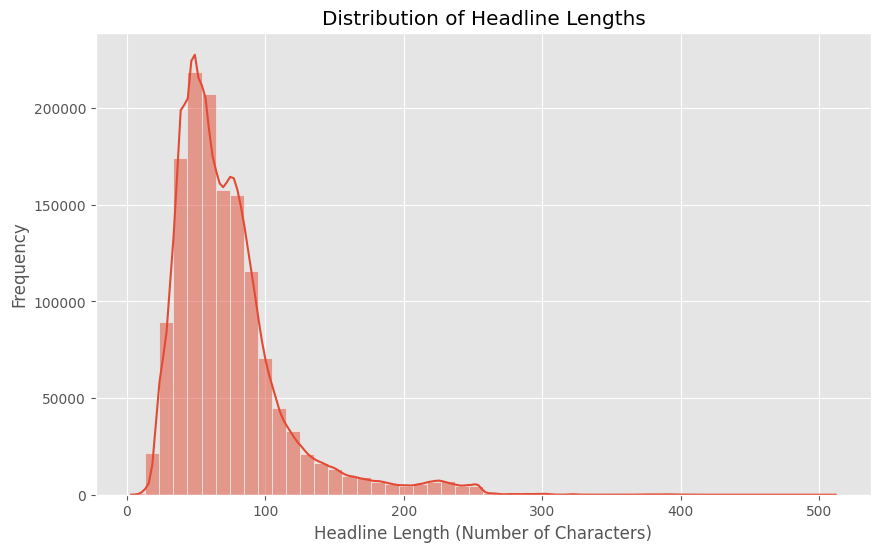


Examples of shortest headlines:
530954    SPY
530955    SRS
602684    J.P
678958    AMJ
912819    J.P
Name: headline, dtype: object

Examples of longest headlines:
701748    JinkoSolar Tiger Pro Series Receives World's F...
238137    Check Point® Software Technologies Ltd. (NASDA...
39028     Shares of several financial services companies...
140048    Shares of several financial services companies...
140381    Shares of several financial services companies...
Name: headline, dtype: object


In [ ]:
# --- Replace 'headline' with the actual name of your headline column ---
actual_headline_column = 'headline' # <--- CHANGE THIS IF NEEDED

if not df.empty and actual_headline_column in df.columns:
    # Ensure the headline column is string type, fill NaN with empty string to avoid errors with len()
    df[actual_headline_column] = df[actual_headline_column].astype(str).fillna('')

    df['headline_length'] = df[actual_headline_column].apply(len)

    print("\nDescriptive statistics for headline length:")
    print(df['headline_length'].describe())

    plt.figure(figsize=(10, 6))
    sns.histplot(df['headline_length'], kde=True, bins=50) # Using more bins if you have lots of data
    plt.title('Distribution of Headline Lengths')
    plt.xlabel('Headline Length (Number of Characters)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    # Check for very short or very long headlines
    print("\nExamples of shortest headlines:")
    print(df.loc[df['headline_length'].nsmallest(5).index, actual_headline_column])

    print("\nExamples of longest headlines:")
    print(df.loc[df['headline_length'].nlargest(5).index, actual_headline_column])

else:
    if df.empty:
        print("DataFrame is empty. Skipping headline length analysis.")
    else:
        print(f"Headline column '{actual_headline_column}' not found. Skipping headline length analysis.")
        print(f"Available columns: {df.columns.tolist()}")


Number of articles per publisher:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
                      ...  
MoneyGeek                 1
muathe                    1
Robert Morris             1
LeftCoastHedgie           1
Jeremie Capron            1
Name: count, Length: 1034, dtype: int64

Total unique publishers: 1034


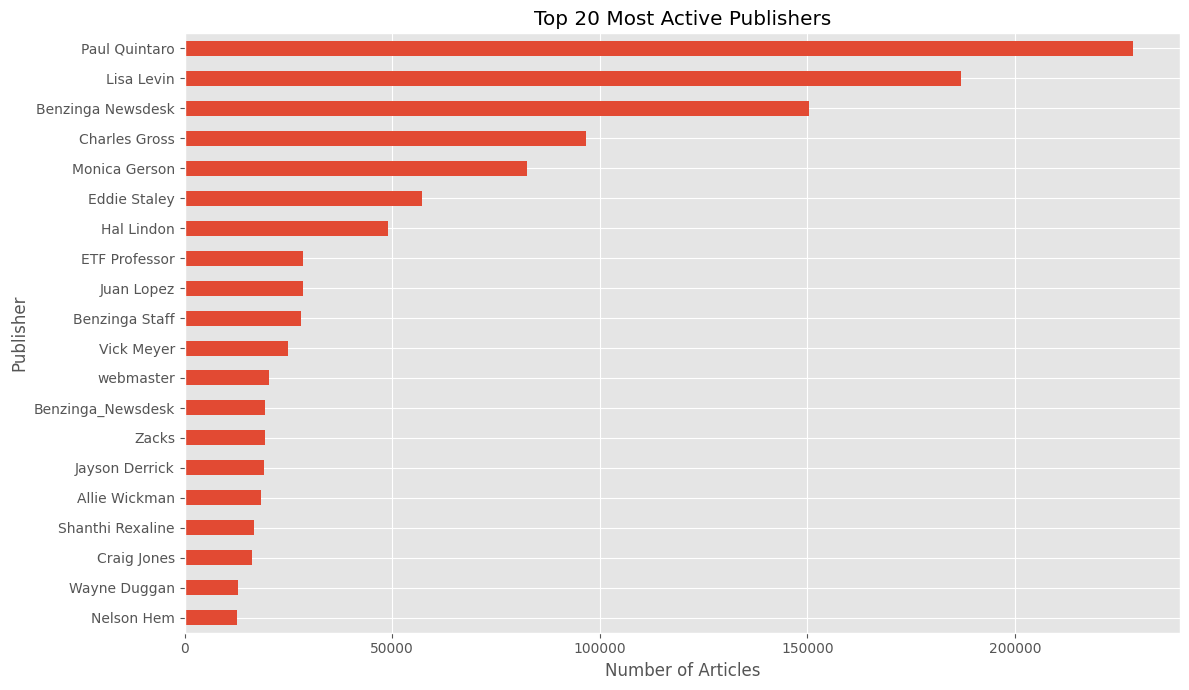

In [ ]:
# --- Replace 'publisher' with the actual name of your publisher column ---
actual_publisher_column = 'publisher' # <--- CHANGE THIS IF NEEDED

if not df.empty and actual_publisher_column in df.columns:
    # Ensure the publisher column is string type for value_counts, fill NaN with 'Unknown' or drop
    df[actual_publisher_column] = df[actual_publisher_column].fillna('Unknown')

    print("\nNumber of articles per publisher:")
    publisher_counts = df[actual_publisher_column].value_counts()
    print(publisher_counts)

    # How many unique publishers?
    print(f"\nTotal unique publishers: {len(publisher_counts)}")

    # Visualize top N publishers
    N = 20 # Show top 20, adjust as needed
    if len(publisher_counts) > 0:
        plt.figure(figsize=(12, max(7, N*0.3))) # Adjust height based on N
        publisher_counts.head(N).plot(kind='barh') # Horizontal bar plot can be better for many categories
        plt.title(f'Top {min(N, len(publisher_counts))} Most Active Publishers')
        plt.xlabel('Number of Articles')
        plt.ylabel('Publisher')
        plt.gca().invert_yaxis() # To show the top publisher at the top
        plt.tight_layout()
        plt.show()
    else:
        print("No publisher data to plot.")

else:
    if df.empty:
        print("DataFrame is empty. Skipping publisher analysis.")
    else:
        print(f"Publisher column '{actual_publisher_column}' not found. Skipping publisher analysis.")
        print(f"Available columns: {df.columns.tolist()}")

<ipython-input-13-d194273ac879>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_dates_df['year'] = valid_dates_df['datetime_utc4'].dt.year
<ipython-input-13-d194273ac879>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_dates_df['month'] = valid_dates_df['datetime_utc4'].dt.month
<ipython-input-13-d194273ac879>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati


DataFrame with new date components (sample):
              datetime_utc4  year  month day_of_week  hour   date_only
0 2020-06-05 10:30:54-04:00  2020      6      Friday    10  2020-06-05
1 2020-06-03 10:45:20-04:00  2020      6   Wednesday    10  2020-06-03
2 2020-05-26 04:30:07-04:00  2020      5     Tuesday     4  2020-05-26
3 2020-05-22 12:45:06-04:00  2020      5      Friday    12  2020-05-22
4 2020-05-22 11:38:59-04:00  2020      5      Friday    11  2020-05-22


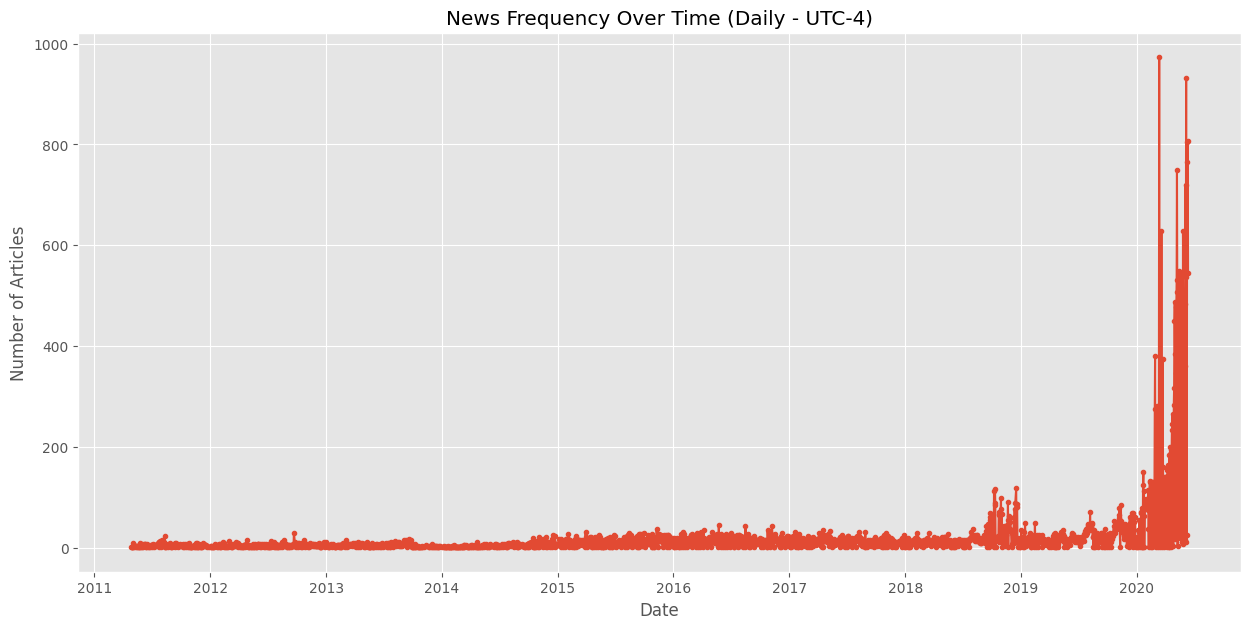

<ipython-input-13-d194273ac879>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=valid_dates_df.sort_values('year'), x='year', palette='viridis')


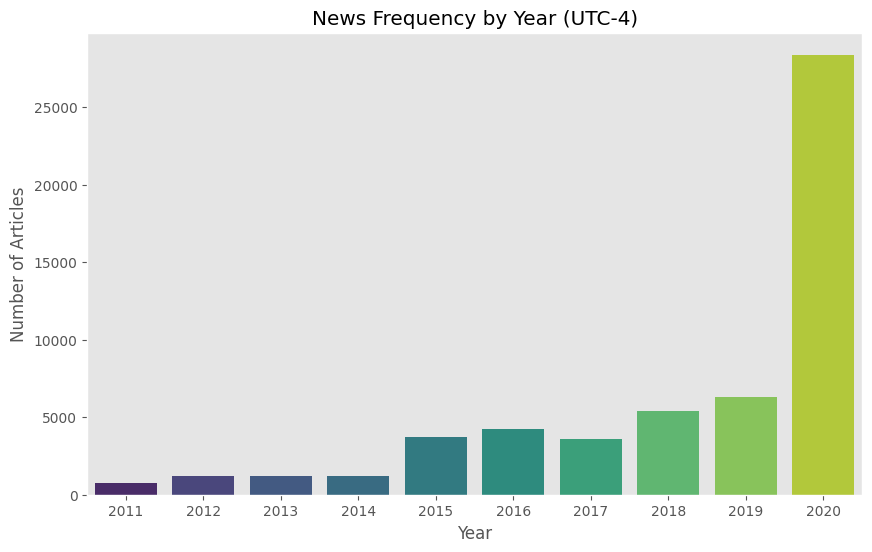

<ipython-input-13-d194273ac879>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=valid_dates_df.sort_values('month'), x='month', palette='magma')


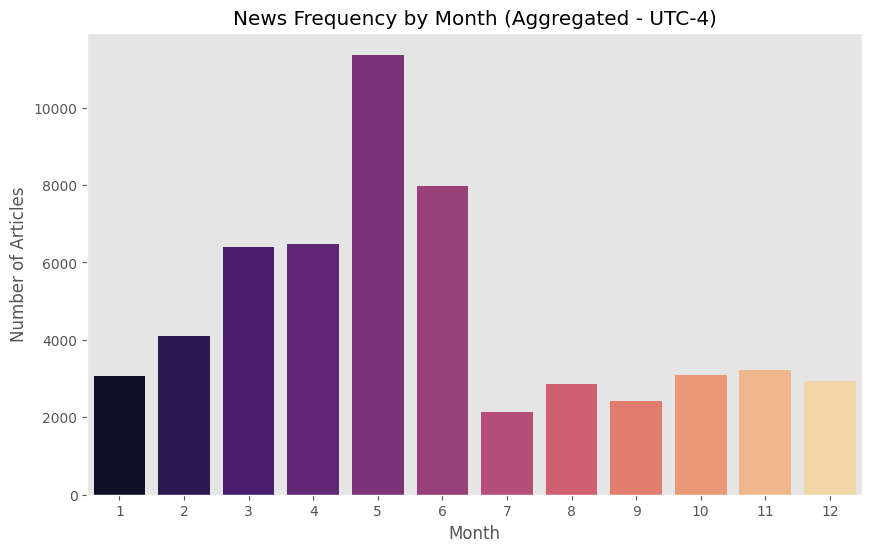

<ipython-input-13-d194273ac879>:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=valid_dates_df, x='day_of_week', order=day_order, palette='Spectral')


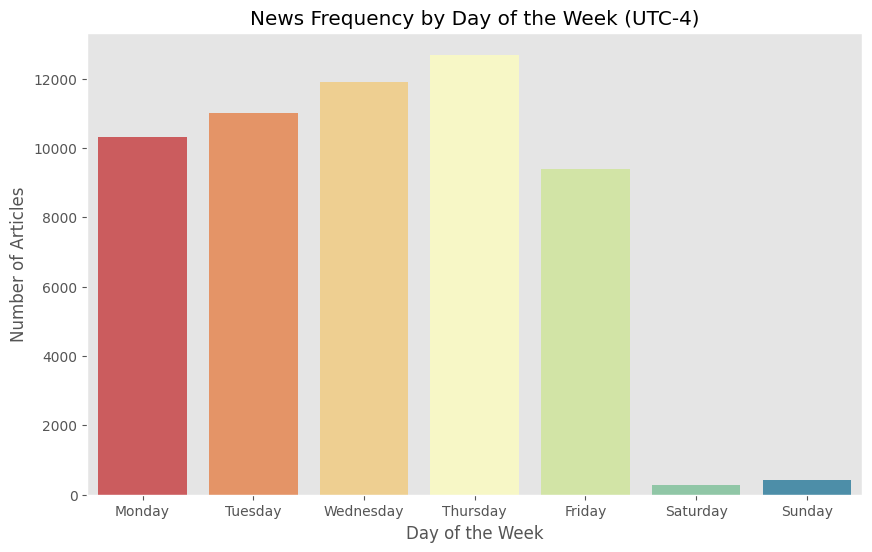

<ipython-input-13-d194273ac879>:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=valid_dates_df, x='hour', palette='coolwarm')


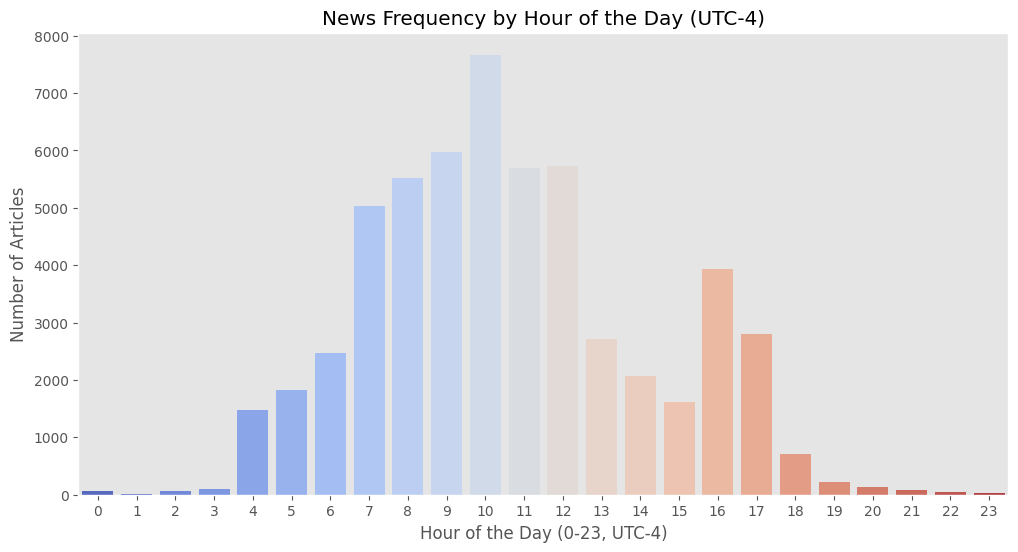

In [ ]:
if not df.empty and 'datetime_utc4' in df.columns and df['datetime_utc4'].notnull().any():
    # Extract components for trend analysis
    # Ensure no errors if datetime_utc4 has NaT values by dropping them for these calculations
    valid_dates_df = df.dropna(subset=['datetime_utc4'])

    if not valid_dates_df.empty:
        valid_dates_df['year'] = valid_dates_df['datetime_utc4'].dt.year
        valid_dates_df['month'] = valid_dates_df['datetime_utc4'].dt.month
        valid_dates_df['day_of_week'] = valid_dates_df['datetime_utc4'].dt.day_name()
        valid_dates_df['hour'] = valid_dates_df['datetime_utc4'].dt.hour
        valid_dates_df['date_only'] = valid_dates_df['datetime_utc4'].dt.date # For daily counts

        print("\nDataFrame with new date components (sample):")
        print(valid_dates_df[['datetime_utc4', 'year', 'month', 'day_of_week', 'hour', 'date_only']].head())

        # Plot news frequency over time (daily) - if data spans a reasonable period
        daily_counts = valid_dates_df.groupby('date_only').size()
        if len(daily_counts) > 1: # Only plot if more than one day of data
            plt.figure(figsize=(15, 7))
            daily_counts.plot(kind='line', marker='.')
            plt.title('News Frequency Over Time (Daily - UTC-4)')
            plt.xlabel('Date')
            plt.ylabel('Number of Articles')
            plt.grid(True)
            plt.show()
        else:
            print("\nNot enough distinct days in data for a meaningful daily trend plot over time.")

        # Plot news frequency by year
        if valid_dates_df['year'].nunique() > 1:
            plt.figure(figsize=(10, 6))
            sns.countplot(data=valid_dates_df.sort_values('year'), x='year', palette='viridis')
            plt.title('News Frequency by Year (UTC-4)')
            plt.xlabel('Year')
            plt.ylabel('Number of Articles')
            plt.grid(axis='y')
            plt.show()
        else:
            print("\nData is within a single year or no year data to plot.")


        # Plot news frequency by month (aggregated across years)
        if valid_dates_df['month'].nunique() > 1:
            plt.figure(figsize=(10, 6))
            sns.countplot(data=valid_dates_df.sort_values('month'), x='month', palette='magma')
            plt.title('News Frequency by Month (Aggregated - UTC-4)')
            plt.xlabel('Month')
            plt.ylabel('Number of Articles')
            plt.grid(axis='y')
            plt.show()
        else:
            print("\nData is within a single month or no month data to plot.")


        # Plot news frequency by day of the week
        day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
        plt.figure(figsize=(10, 6))
        sns.countplot(data=valid_dates_df, x='day_of_week', order=day_order, palette='Spectral')
        plt.title('News Frequency by Day of the Week (UTC-4)')
        plt.xlabel('Day of the Week')
        plt.ylabel('Number of Articles')
        plt.grid(axis='y')
        plt.show()

        # Plot news frequency by hour of the day
        plt.figure(figsize=(12, 6))
        sns.countplot(data=valid_dates_df, x='hour', palette='coolwarm')
        plt.title('News Frequency by Hour of the Day (UTC-4)')
        plt.xlabel('Hour of the Day (0-23, UTC-4)')
        plt.ylabel('Number of Articles')
        plt.xticks(ticks=range(0,24)) # Ensure all hours are shown
        plt.grid(axis='y')
        plt.show()
    else:
        print("No valid datetime_utc4 data to analyze for trends.")
else:
    if df.empty:
        print("DataFrame is empty. Skipping date/time trend analysis.")
    else:
        print("'datetime_utc4' column not found or contains all NaT. Skipping date/time trend analysis.")

In [ ]:
# --- DEFINE YOUR ACTUAL COLUMN NAMES ---
# Replace these with the real names from your raw_analyst_ratings.csv
actual_headline_column = 'headline'  # e.g., 'title', 'ArticleHeadline'
actual_publisher_column = 'publisher' # e.g., 'Source', 'NewsProvider'
actual_stock_column = 'stock'       # e.g., 'Ticker', 'Symbol'
# actual_date_column_name = 'date' # Already used in date processing

print("Column name variables confirmed for subsequent cells:")
print(f"Headline column: {actual_headline_column}")
print(f"Publisher column: {actual_publisher_column}")
print(f"Stock column: {actual_stock_column}")

Column name variables confirmed for subsequent cells:
Headline column: headline
Publisher column: publisher
Stock column: stock



Performing basic text analysis on column: 'headline'

Top 25 most common words in headlines (after basic cleaning):
stocks: 161868
est: 140605
eps: 128929
shares: 114209
reports: 108707
update: 91680
market: 90880
earnings: 87185
sales: 79526
top: 78678
week: 67669
announces: 66529
price: 64232
buy: 64060
downgrades: 61942
trading: 61158
benzingas: 57985
raises: 57798
upgrades: 56804
target: 54620
maintains: 52961
higher: 48163
new: 48061
session: 45326
inc: 44917


<ipython-input-25-f34ca2d9fcd8>:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=common_words_df, x='count', y='word', palette='mako')


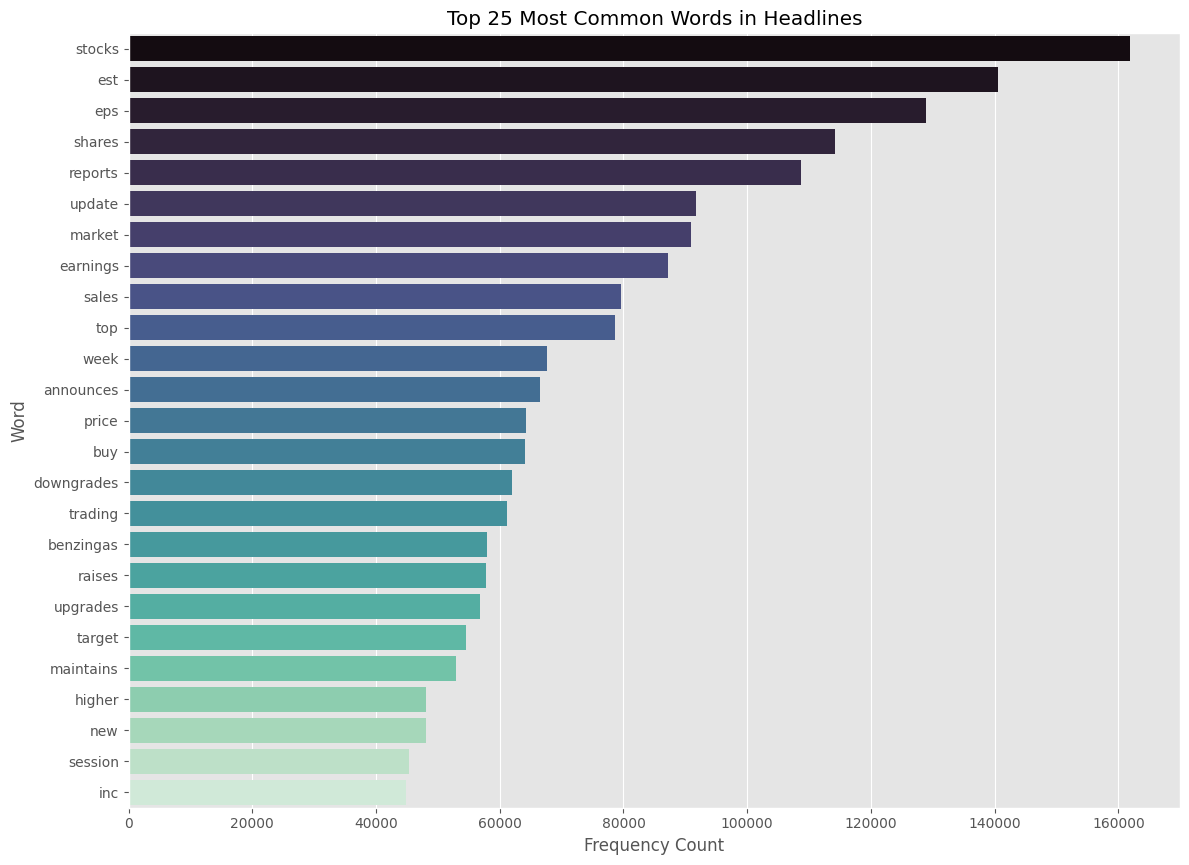

In [ ]:
# Ensure NLTK resources are available
import nltk
import re # Ensure re is imported
from collections import Counter # Ensure Counter is imported
# matplotlib and seaborn should have been imported earlier, but good to ensure for standalone cell
import matplotlib.pyplot as plt
import seaborn as sns
# For NLTK text processing
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download('stopwords', quiet=True)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading NLTK punkt tokenizer models...")
    nltk.download('punkt', quiet=True)
try:
    nltk.data.find('tokenizers/punkt_tab') # For the specific error you encountered
except LookupError:
    print("Downloading NLTK punkt_tab resource...")
    nltk.download('punkt_tab', quiet=True)

# Check if df and actual_headline_column are defined and valid
if 'df' not in locals() or df.empty:
    print("DataFrame 'df' is not loaded or is empty. Please load data first.")
elif 'actual_headline_column' not in globals() or actual_headline_column is None:
    print("Variable 'actual_headline_column' is not defined. Please define it with the name of your headline column.")
elif actual_headline_column not in df.columns:
    print(f"Headline column '{actual_headline_column}' not found. Skipping common word analysis.")
    print(f"Available columns: {df.columns.tolist()}")
else:
    print(f"\nPerforming basic text analysis on column: '{actual_headline_column}'")

    text_df = df.copy() # Work on a copy
    text_df[actual_headline_column] = text_df[actual_headline_column].astype(str).fillna('')
    all_headlines_text = ' '.join(text_df[actual_headline_column]).lower()
    all_headlines_text = re.sub(r'[^\w\s]', '', all_headlines_text) # Remove punctuation
    all_headlines_text = re.sub(r'\d+', '', all_headlines_text)     # Remove digits

    words = []
    try:
        words = word_tokenize(all_headlines_text)
    except Exception as e:
        print(f"Error during word_tokenize: {e}")

    if words:
        stop_words_list = set(stopwords.words('english'))
        # Add custom stopwords if needed
        # custom_stopwords_to_add = {'stock', 'company', 'inc', 'corp', 'shares', 'market', 'analyst', 'rating'}
        # stop_words_list.update(custom_stopwords_to_add)

        filtered_words = [
            word for word in words
            if word.isalpha() and word not in stop_words_list and len(word) > 2 # Min word length
        ]

        if filtered_words:
            word_counts = Counter(filtered_words)
            num_top_words = 25
            print(f"\nTop {num_top_words} most common words in headlines (after basic cleaning):")
            most_common_words = word_counts.most_common(num_top_words)
            for word_val, count_val in most_common_words:
                print(f"{word_val}: {count_val}")

            common_words_df = pd.DataFrame(most_common_words, columns=['word', 'count'])
            plt.figure(figsize=(12, max(8, num_top_words * 0.35)))
            sns.barplot(data=common_words_df, x='count', y='word', palette='mako')
            plt.title(f'Top {num_top_words} Most Common Words in Headlines')
            plt.xlabel('Frequency Count')
            plt.ylabel('Word')
            plt.tight_layout()
            plt.show()
        else:
            print("No words found after filtering (e.g., all words were stopwords, too short, or non-alphabetic).")
    elif not words and all_headlines_text:
        print("Tokenization resulted in no words, or an error occurred. Cannot proceed with word count.")
    elif not all_headlines_text:
        print("The combined headline text is empty. Nothing to tokenize or count.")


Analyzing stock symbols in column: 'stock'

Top 10 stock symbols by news volume:
stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
Name: count, dtype: int64
... and 6194 more stock symbols.

Total unique stock symbols found (including 'Unknown_Stock' if any): 6204


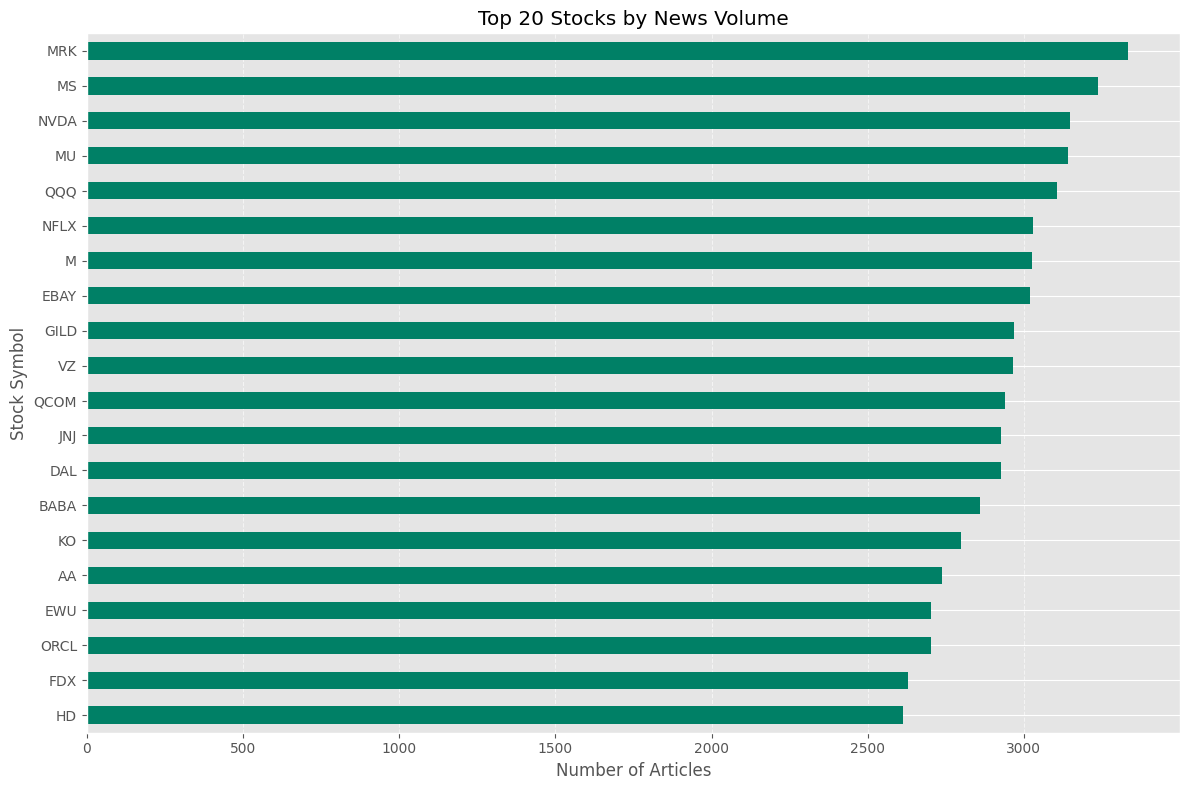


Stocks shown in the plot (top 20):
stock
MRK     3333
MS      3238
NVDA    3146
MU      3142
QQQ     3106
NFLX    3028
M       3025
EBAY    3018
GILD    2968
VZ      2966
QCOM    2941
JNJ     2928
DAL     2926
BABA    2858
KO      2797
AA      2739
EWU     2702
ORCL    2701
FDX     2629
HD      2612
Name: count, dtype: int64


In [ ]:
# This cell assumes 'df' is your loaded DataFrame and 'actual_stock_column' has been defined.

if 'df' not in locals() or df.empty:
    print("DataFrame 'df' is not loaded or is empty. Please load data first.")
elif 'actual_stock_column' not in globals() or actual_stock_column is None:
    print("Variable 'actual_stock_column' is not defined. Please define it with the name of your stock column.")
elif actual_stock_column not in df.columns:
    print(f"Stock column '{actual_stock_column}' (as defined) not found in DataFrame.")
    print(f"Available columns: {df.columns.tolist()}")
    print("Skipping stock symbol analysis.")
else:
    print(f"\nAnalyzing stock symbols in column: '{actual_stock_column}'")

    stock_analysis_df = df.copy() # Work on a copy

    # Convert to string, fill NaNs, and convert to uppercase for consistency
    stock_analysis_df[actual_stock_column] = stock_analysis_df[actual_stock_column].astype(str).fillna('Unknown_Stock').str.upper()

    # Optional: Further cleanup (e.g., remove exchange suffixes like .O, .N)
    # stock_analysis_df[actual_stock_column] = stock_analysis_df[actual_stock_column].str.replace(r'\.[A-Z]$', '', regex=True) # Removes . followed by any single capital letter
    # stock_analysis_df[actual_stock_column] = stock_analysis_df[actual_stock_column].str.strip() # Remove leading/trailing whitespace

    stock_counts = stock_analysis_df[actual_stock_column].value_counts()

    print("\nTop 10 stock symbols by news volume:")
    print(stock_counts.head(10))
    if len(stock_counts) > 10:
        print(f"... and {len(stock_counts) - 10} more stock symbols.")

    print(f"\nTotal unique stock symbols found (including 'Unknown_Stock' if any): {len(stock_counts)}")
    if 'Unknown_Stock' in stock_counts.index:
        print(f"Number of articles with 'Unknown_Stock': {stock_counts.get('Unknown_Stock', 0)}")

    N_stocks_to_plot = 20

    plot_stock_counts = stock_counts.copy()
    # Refined logic for excluding 'Unknown_Stock' from plot
    if 'Unknown_Stock' in plot_stock_counts.index:
        is_unknown_dominant = plot_stock_counts.index.get_loc('Unknown_Stock') < N_stocks_to_plot
        if not is_unknown_dominant and len(plot_stock_counts) > N_stocks_to_plot : # If not in top N and more than N stocks
            plot_stock_counts = plot_stock_counts.drop('Unknown_Stock', errors='ignore')
        elif len(plot_stock_counts) > 1 and plot_stock_counts.get('Unknown_Stock', 0) < (plot_stock_counts.drop('Unknown_Stock', errors='ignore').max() * 0.05) and not is_unknown_dominant:
            plot_stock_counts = plot_stock_counts.drop('Unknown_Stock', errors='ignore')


    if not plot_stock_counts.empty:
        # Ensure we don't try to plot more than available unique stocks
        num_to_display = min(N_stocks_to_plot, len(plot_stock_counts))

        plt.figure(figsize=(12, max(7, num_to_display * 0.4)))
        plot_stock_counts.head(num_to_display).plot(kind='barh', colormap='summer')
        plt.title(f'Top {num_to_display} Stocks by News Volume')
        plt.xlabel('Number of Articles')
        plt.ylabel('Stock Symbol')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        print(f"\nStocks shown in the plot (top {num_to_display}):")
        print(plot_stock_counts.head(num_to_display))

    elif not stock_counts.empty:
        print("Plotting skipped: Only 'Unknown_Stock' or too few actual stocks to plot.")
        print("Original counts (may include 'Unknown_Stock'):")
        print(stock_counts.head(N_stocks_to_plot))
    else:
        print("No stock symbol data found to plot.")

In [ ]:
# This cell assumes 'df' is your loaded DataFrame and 'actual_publisher_column' has been defined.

if 'df' not in locals() or df.empty:
    print("DataFrame 'df' is not loaded or is empty. Please load data first.")
elif 'actual_publisher_column' not in globals() or actual_publisher_column is None:
    print("Variable 'actual_publisher_column' is not defined. Please define it with the name of your publisher column.")
elif actual_publisher_column not in df.columns:
    print(f"Publisher column '{actual_publisher_column}' (as defined) not found in DataFrame.")
    print(f"Available columns: {df.columns.tolist()}")
    print("Skipping publisher analysis.")
else:
    print(f"\nAnalyzing publisher column '{actual_publisher_column}' for potential domain/source extraction.")

    publisher_analysis_df = df.copy() # Work on a copy
    publisher_analysis_df[actual_publisher_column] = publisher_analysis_df[actual_publisher_column].astype(str).fillna('Unknown_Publisher')

    def extract_source_from_publisher(publisher_name):
        if pd.isna(publisher_name) or publisher_name == 'Unknown_Publisher':
            return 'Unknown_Publisher'

        name_lower = str(publisher_name).lower()

        # Try to extract from email-like strings
        if '@' in name_lower:
            try:
                domain = name_lower.split('@')[1]
                parts = domain.split('.')
                # Handle common patterns like 'mail.example.com' -> 'example.com'
                # or 'news.alerts.example.co.uk' -> 'example.co.uk'
                if len(parts) > 2 and parts[0] in ['mail', 'email', 'news', 'alerts', 'info', 'contact']:
                    domain = '.'.join(parts[1:])
                # Basic TLD check to avoid overly short domains like 'com' if something went wrong
                if '.' in domain and len(domain.split('.')[0]) > 1 :
                     return domain
                else: # if domain becomes too short or invalid, return original publisher name
                    return publisher_name
            except IndexError:
                return publisher_name # Return original on unexpected split error

        # Add other specific rules if you notice patterns
        # e.g., "News Outlet via WireService" -> "WireService"
        # if ' via ' in name_lower:
        #     return name_lower.split(' via ')[-1].strip()

        # Remove common suffixes like " Inc.", " LLC", " Ltd." for grouping
        name_clean = re.sub(r'\s+(inc|llc|ltd|corp|corporation|limited|incorporated)\.?$', '', name_lower, flags=re.IGNORECASE)
        name_clean = name_clean.strip()

        return name_clean if name_clean else publisher_name # return cleaned name or original if cleaning results in empty

    publisher_analysis_df['publisher_source_guess'] = publisher_analysis_df[actual_publisher_column].apply(extract_source_from_publisher)

    original_publisher_counts_num = publisher_analysis_df[actual_publisher_column].nunique()
    guessed_source_counts_num = publisher_analysis_df['publisher_source_guess'].nunique()

    print(f"\nNumber of unique original publishers: {original_publisher_counts_num}")
    print(f"Number of unique 'guessed' publisher sources: {guessed_source_counts_num}")

    if guessed_source_counts_num < original_publisher_counts_num * 0.95 and guessed_source_counts_num > 0: # If significant reduction
        print("Publisher source guessing has potentially consolidated some entries.")

        N_sources_to_plot = 15
        source_value_counts = publisher_analysis_df['publisher_source_guess'].value_counts()

        # Ensure we don't try to plot more than available unique sources
        num_to_display_sources = min(N_sources_to_plot, len(source_value_counts))

        if num_to_display_sources > 0 :
            plt.figure(figsize=(12, max(7, num_to_display_sources * 0.4)))
            source_value_counts.head(num_to_display_sources).plot(kind='barh', colormap='Pastel1')
            plt.title(f'Top {num_to_display_sources} Guessed Publisher Sources by Article Count')
            plt.xlabel('Number of Articles')
            plt.ylabel('Guessed Publisher Source')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()

            print(f"\nGuessed sources shown in plot (top {num_to_display_sources}):")
            print(source_value_counts.head(num_to_display_sources))
        else:
            print("No guessed publisher sources to plot after processing.")

    elif guessed_source_counts_num > 0 :
        print("Publisher source guessing did not significantly consolidate names, or names were already fairly clean.")
        print("Top 10 original publishers for reference:")
        print(publisher_analysis_df[actual_publisher_column].value_counts().head(10))
    else:
        print("No publisher source data found to plot.")


Analyzing publisher column 'publisher' for potential domain/source extraction.

Number of unique original publishers: 1034
Number of unique 'guessed' publisher sources: 1024
Publisher source guessing did not significantly consolidate names, or names were already fairly clean.
Top 10 original publishers for reference:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64
